## **Chatbot with Multiple Tools**
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [19]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from IPython.display import Image, display
from typing import Annotated
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition

In [2]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [3]:
api_wrapper_arxiv = ArxivAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)

arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [4]:
result = arxiv.invoke("Attention is all you need")
print(result)

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [6]:
api_wrapper_wiki = WikipediaAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)

wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [7]:
result = wiki.invoke("What is machine learning")
print(result)

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m


In [9]:
tavily = TavilySearchResults()

C:\Users\Sohan\AppData\Local\Temp\ipykernel_11208\2290291758.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [11]:
tavily.invoke("Provide me recent AI news for May 2026")

[{'title': 'Google AI announcements from May 2026',
  'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-may-2026',
  'content': 'The big picture\n\nMay 2026 was packed with AI news. At Google I/O 2026, we officially entered the agentic Gemini era with the launch of Gemini 3.5 — which delivers frontier intelligence for agents and coding — and Gemini Omni, where Gemini’s ability to reason meets the ability to create. The Android Show set the stage with brand-new hardware built specifically for these tools, including the Googlebook from our hardware partners. We also broadened our personal wellness tools with the new Google Health app and Fitbit Air, and launched an initiative to apply advanced quantum science and AI to the life sciences. Ultimately, May was all about making AI more proactive, helpful and integrated into your everyday life.\n\nAI that helps you create and explore [...] ## General summary\n\nGoogle’s May 2026 updates center on the new "agentic" 

In [12]:
# Combine all tools in the list
tools = [arxiv, wiki, tavily]

In [16]:
# Initialize LLM model
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")
llm_with_tools = llm.bind_tools(tools)

In [18]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI news?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'rz5bh41qw',
  'type': 'tool_call'}]

In [20]:
## Create a chatbot with LangGraph
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Node definition
def tool_call_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_call_llm", tool_call_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_call_llm")

builder.add_conditional_edges(
    "tool_call_llm",
    tools_condition
)

builder.add_edge("tool_call_llm", END)

graph_builder = builder.compile()

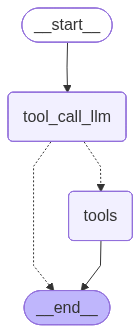

In [21]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [27]:
# Invocation
messages = graph_builder.invoke({"messages": HumanMessage(content="What is attention is all you need?")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is attention is all you need?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (wayrc9vwa)
 Call ID: wayrc9vwa
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Attention Is All You Need - Wikipedia", "url": "https://en.wikipedia.org/wiki/Attention_Is_All_You_Need", "content": "\"Attention Is All You Need\"( is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer \"Transformer (deep learning)\"), based on the attention mechanism proposed in 2014 by Bahdanau _et al._( The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence 

In [28]:
# Invocation
messages = graph_builder.invoke({"messages": HumanMessage(content="What is recent war news?")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is recent war news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (g2p53xg52)
 Call ID: g2p53xg52
  Args:
    query: recent war news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "US-Israel war with Iran | Latest News and Updates | BBC News", "url": "https://www.bbc.com/news/topics/cx2jyv8j8gwt", "content": "## Tehran will never cede control of Strait of Hormuz, senior Iranian politician tells BBC\n\nLyse Doucet speaks to Ebrahim Azizi, who says Iran \"will decide the right of passage\" through the crucial shipping route.\n\nLyse Doucet in Tehran\n\n## Lyse Doucet: Most Iranians don't expect this truce to last\n\nThe BBC's Lyse Doucet reports from Tehran as tensions continue over the Strait of Hormuz.\n\nPetrol drips out of a fuel hose at a petrol

In [57]:
# # Invocation
# messages = graph_builder.invoke({"messages": HumanMessage(content="What is machine learning?")})

# for message in messages["messages"]:
#     message.pretty_print()